# Week 4 Activity: Data Exploration (Welltory COVID-19 and Wearables Dataset)

## Data Context and Sampling

This analysis explores heart rate variability (HRV) measurements collected Welltory in 2020 from users who tracked symptoms during the COVID-19 pandemics. Data was self-collected via smartphone PPG (camera-based) or Bluetooth heart rate monitors combined with self-reported demographics and symptom surveys.

Data used: 
- hrv_measurements.csv (individual HRV readings)
- participants.csv (demographics: gender, age range, city, country, height, weight)
- weather.csv (daily weather by user location)

Considerations about the sampling (possible sampling limitations): This is a sample of Welltory app users who volunteered during a reseatch initiative rather than a random or representative sample of the general population or of COVID-19 patients broadly. Thus, it is important to keep in mind possible biases like selection, volunteer, or response bias.

In [60]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt

# Load the three datasets

hrv = pd.read_csv("../data/hrv_measurements.csv")
participants = pd.read_csv("../data/participants.csv")
weather = pd.read_csv("../data/weather.csv")

print(f"hrv_measurements: {hrv.head()}")
print(f"participants: {participants.head()}")
print(f"weather: {weather.head()}")

hrv_measurements:     user_code     rr_code measurement_datetime time_of_day  bpm  meanrr  \
0  007b8190cf  10489a6aea  2020-04-21 21:23:08     morning   75  795.90   
1  007b8190cf  9610d4d4dc  2020-04-26 11:19:25     morning   70  858.00   
2  013f6d3e5b  f3de056155  2020-05-15 04:14:21       night   83  724.10   
3  013f6d3e5b  b04489e32f  2020-05-19 03:06:02       night   75  802.64   
4  01bad5a519  ac52c706c6  2019-12-31 09:07:43     morning   78  768.07   

   mxdmn    sdnn   rmssd  pnn50  ...     lf      hf     vlf   lfhf  \
0   0.12  45.802  54.174  15.15  ...  508.0  1076.0   267.0  0.472   
1   0.11  32.889  33.022  16.16  ...  409.0   310.0   176.0  1.319   
2   0.17  54.811  65.987  17.17  ...  432.0   881.0   194.0  0.490   
3   0.20  72.223  70.039  22.22  ...  814.0  1487.0  1719.0  0.547   
4   0.10  29.650  21.196   4.04  ...  489.0   128.0    96.0  3.820   

   total_power  how_feel  how_mood  how_sleep  \
0       1851.0         0        -1        NaN   
1        895

# Data Structure

## Questions we are asking:

- What are the dimensions of each data set?
- What are the data types of the variables?
- Are there missing values, and how are they represented? 

In [61]:
for name, df in [("hrv_measurements", hrv), ("participants", participants), ("weather", weather)]:
    print(f"{name}:")
    print(f"\nDimensions: {df.shape}")
    print(f"\nData Types:\n{df.dtypes}")
    print(f"\nMissing Values:\n{df.isnull().sum()}")

hrv_measurements:

Dimensions: (3245, 22)

Data Types:
user_code                object
rr_code                  object
measurement_datetime     object
time_of_day              object
bpm                       int64
meanrr                  float64
mxdmn                   float64
sdnn                    float64
rmssd                   float64
pnn50                   float64
mode                    float64
amo                     float64
lf                      float64
hf                      float64
vlf                     float64
lfhf                    float64
total_power             float64
how_feel                  int64
how_mood                  int64
how_sleep               float64
tags                     object
rr_data                  object
dtype: object

Missing Values:
user_code                  0
rr_code                    0
measurement_datetime       0
time_of_day                0
bpm                        0
meanrr                     0
mxdmn                      0
sdnn   

## Interpretation

The core HRV metrics (bpm, sdnn, rmssd, lf, hf, etc.) have no missing values, which is reassuring for reliability of the primary analysis. However, `how_sleep` is missing in over half of hrv_measurements rows (1779/3245) and `tags` in about 32% (1044/3245), so these shouldn't be used without accounting for the gap (can either drop them from correlation analysis or treating missingness as its own category). In participants, missingness is minor (2-12 rows) for demographic fields, but symptoms_onset is missing in 38 of 185 participants. This is likely because not everyone reported a symptom onset date or hadn't developed symptoms yet. weather.csv itself has no missing values, but this is because it only contains records for 104 of 185 total users, so the "missingness" here is really a coverage gap at the user level rather than missing data within the table like with the other two datasets we talked about.

# Descriptive Statistics

## Questions we are asking:
- What are the central tendency measures for numerical variables (mean/median)?
- What are the measures of dispersion for numerical variables (standard deviation/minimum/maximum)?
- What is the distribution of the variables (normal/skewed/etc)?

In [62]:
numeric_columns = hrv.select_dtypes(include=[np.number]).columns

print("Central Tendency Measures:")
print(hrv[numeric_columns].describe().loc[['mean', '50%']])

print("\nDispersion Measures:")
print(hrv[numeric_columns].describe().loc[['std', 'min', 'max']])

print("\nDistribution Measures (Skewness):")
print(hrv[numeric_columns].skew())

print("\nDistribution Measures (Kurtosis):")
print(hrv[numeric_columns].kurt())

Central Tendency Measures:
            bpm      meanrr     mxdmn       sdnn      rmssd      pnn50  \
mean  73.257935  839.600366  0.184635  52.489218  52.814196  20.615609   
50%   72.000000  829.100000  0.160000  46.919000  42.869000  16.160000   

          mode       amo          lf           hf         vlf      lfhf  \
mean  0.837465  46.78829  927.038213  1125.041294  578.229892  2.397769   
50%   0.825000  45.00000  423.000000   380.000000  293.000000  0.862000   

      total_power  how_feel  how_mood  how_sleep  
mean  2630.309399 -0.235439 -0.076733  -0.065484  
50%   1387.000000  0.000000  0.000000   0.000000  

Dispersion Measures:
            bpm       meanrr     mxdmn        sdnn       rmssd      pnn50  \
std   12.201088   137.420367  0.107456   29.369506   39.353213  18.588156   
min   44.000000   477.730000  0.030000    9.515000    6.340000   0.000000   
max  125.000000  1346.740000  0.790000  206.631000  310.800000  91.920000   

         mode        amo            lf  

In [63]:
participants_numeric = participants.select_dtypes(include=[np.number]).columns
weather_numeric = weather.select_dtypes(include=[np.number]).columns

print("Participants:")
print(participants[participants_numeric].describe())

print("\nWeather")
print(weather[weather_numeric].describe())

Participants:
           height      weight
count  183.000000  185.000000
mean   169.976393   77.927757
std     12.400103   19.552541
min    132.080000   43.500000
25%    163.500000   63.500000
50%    168.000000   74.344000
75%    174.500000   90.537000
max    250.000000  154.221000

Weather
       avg_temperature_C  atmospheric_pressure  precip_intensity     humidity  \
count        1717.000000           1717.000000       1717.000000  1717.000000   
mean           11.839221           1014.111639          0.003803    66.376586   
std             7.769565              8.356792          0.015348    19.339670   
min           -13.150000            984.300000          0.000000     3.000000   
25%             6.472200           1009.000000          0.000000    54.000000   
50%            11.272200           1014.100000          0.000200    68.000000   
75%            16.663900           1019.566700          0.001700    81.000000   
max            44.072200           1047.750000          0.2

## Interpretation

Height and weight in participants.csv appear self-reported and mostly reasonable (median height of about 168cm and median weight of about 74kg), but the maximum height of 250cm is likely a data entry error rather than a true value since that would mean the person is 8 feet tall. This will be further investigated in the Data Quality section. Weather variables (temperature, pressure, precipitation, humidity, clouds) all fall within physically plausible ranges globally with no obvious anomalies. The wide temperature range (-13 degress Celsius to 44 degrees Celsius) reflects that participants are located across many different countries with many different climates, whcih is consistent with participants.csv, which shows that users are from a range of countries.

# Data Quality

## Questions we are asking:
- Are there duplicated rows or inconsistent values?
- Are there outliers or extreme values that need attention?
- Do the values make sense based on the context/domain knowledge?

In [64]:
print("Duplicated Rows:")
print(f"hrv_measurements: {hrv.duplicated().sum()}")
print(f"participants: {participants.duplicated().sum()}")
print(f"weather: {weather.duplicated().sum()}")

print("\nOutlier check for height (participants):")
print(participants[['user_code', 'height', 'weight']].sort_values('height', ascending=False).head())

print("\nOutlier check for HRV metrics (values beyond 3 std from mean):")
for col in ['sdnn', 'rmssd', 'lf', 'hf', 'vlf', 'lfhf', 'total_power']:
    mean, std = hrv[col].mean(), hrv[col].std()
    outliers = hrv[(hrv[col] > mean + 3*std) | (hrv[col] < mean - 3*std)]
    print(f"{col}: {len(outliers)} outliers ({len(outliers)/len(hrv)*100:.1f}%)")

Duplicated Rows:
hrv_measurements: 0
participants: 0
weather: 0

Outlier check for height (participants):
      user_code  height   weight
102  83161408c1  250.00   82.146
49   3fff7627ca  248.92  114.713
83   6ce06ce747  203.00   70.534
175  f8b552df37  193.00   90.000
136  b3c7f65a4b  193.00   65.998

Outlier check for HRV metrics (values beyond 3 std from mean):
sdnn: 82 outliers (2.5%)
rmssd: 103 outliers (3.2%)
lf: 74 outliers (2.3%)
hf: 89 outliers (2.7%)
vlf: 55 outliers (1.7%)
lfhf: 53 outliers (1.6%)
total_power: 94 outliers (2.9%)


## Interpretation

No duplicate rows were found in any of the tables. Two height values (250.00, 248.92) are not physically plausible and are likely data entry errors. For example, it could have been a unit mismatch where the person entered their height in inches or mm instead of cm. These two rows will be treated as missing (NaN) instead of dropping them entirely since the weight and other participant data for these users are still usable. The remaining taller values (193 to 203cm) are reasonable and were kept. HRV metrics (sdnn, rmssd, lf, hf, vlf, lfhf, total_power) show 1.6-3.2% of values flagged as 3+ standard deviation outliers. Given the right-skewed distributions identified in the Descriptive Statistics section, this is expected since a skewed distribution naturally produces more extreme looking values under a threshold based on normal distribution. We will not remove these values because extreme HRV readings can reflect real physiological states like illness or stress, which is likely relevant in this dataset's COVID-19 research context. A log transformation will be applied to these skewed columns in the Data Transformation section to make them more analysis-friendly. 

In [65]:
participants.loc[participants['height'] > 220, 'height'] = np.nan
print(f"Heights over 220cm after cleanup: {(participants['height'] > 220).sum()}")

Heights over 220cm after cleanup: 0


## Data Quality Assessment

Data profiling: 
This data consists of 9 related CSVs joined by `user_code`. The data was collected by the Welltory app from participants that opted in during a COVID-19 research initiative in 2020. `hrv_measurements` contains 3,245 readings across 185 users. `participants` contains demographics for those same 185 users. `weather` covers only 104 of the 185 users.

Completeness:
Core HRV metrics are fully populated (0 missing), but `how_sleep` (55% missing) and `tags` (32% missing) in hrv_measurements, and `symptoms_onset` (20% missing) in participants, are highly incomplete. Also, weather.csv is only 57% complete at the user level (104/185 users).

Accuracy:
Two height values (which I talked about above) were identified as implausible and corrected to missing. HRV outliers (1.6-3.2% per column) were evaluated and determined to be plausible physiological extremes rather than errors, given this dataset's context (illness, stress, varying measurement conditions).

Consistency: 
No duplicate rows were found in any table. Data types are consistent within each column.

Integrity:
Referential integrity between hrv_measurements and participants is strong (100% of hrv_measurements user_codes exist in participants). weather.csv has weaker integrity, covering only 56% of users.

Lineage and provenance: 
This data comes from Welltory, a consumer heart-rate variability tracking app, and was collected via user smartphone cameras (PPG) or Bluetooth heart rate monitors, self-reported demographics, and (for the weather table) an external weather API joined by user location and date rather than being self-reported. The fact that some data was device-measured, some was self-reported, and some was externally-sourced data should be kept in mind when assessing the reliability. For example, device-measured HRV values are likely more reliable than self-reported fields like how_feel.

# Variable Relationships

## Questions we are asking:
- How do HRV metrics relate to participant demographics?
- How do HRV metrics relate to weather conditions?
- Are there strong correlations between the HRV metrics themselves?

In [66]:
# Merge hrv_measurements with participants (many-to-one on user_code)
merged = hrv.merge(participants, on='user_code', how='left')

# Extract date from measurement_datetime to join weather and then merge
merged['day'] = pd.to_datetime(merged['measurement_datetime']).dt.date
weather['day'] = pd.to_datetime(weather['day']).dt.date
merged = merged.merge(weather, on=['user_code', 'day'], how='left')

print(f"Merged shape: {merged.shape}")
print(f"Rows with weather data: {merged['avg_temperature_C'].notna().sum()} ({merged['avg_temperature_C'].notna().mean()*100:.1f}%)")

corr_columns = ['bpm', 'meanrr', 'sdnn', 'rmssd', 'lf', 'hf', 'vlf', 'lfhf', 'total_power', 'how_feel', 'how_mood', 'height', 'weight', 'avg_temperature_C', 'humidity']
correlation_matrix = merged[corr_columns].corr()
print(correlation_matrix)

Merged shape: (3245, 35)
Rows with weather data: 2534 (78.1%)
                        bpm    meanrr      sdnn     rmssd        lf        hf  \
bpm                1.000000 -0.977724 -0.341514 -0.214339 -0.171505 -0.105204   
meanrr            -0.977724  1.000000  0.348052  0.231696  0.176511  0.128630   
sdnn              -0.341514  0.348052  1.000000  0.909046  0.743380  0.773958   
rmssd             -0.214339  0.231696  0.909046  1.000000  0.629966  0.857374   
lf                -0.171505  0.176511  0.743380  0.629966  1.000000  0.601294   
hf                -0.105204  0.128630  0.773958  0.857374  0.601294  1.000000   
vlf               -0.240630  0.242066  0.489891  0.274702  0.338897  0.227192   
lfhf              -0.003373 -0.024851 -0.022080 -0.164167  0.163171 -0.123659   
total_power       -0.184698  0.201795  0.879030  0.841720  0.830744  0.911203   
how_feel          -0.078663  0.085541  0.088479  0.061925  0.047117  0.071503   
how_mood          -0.032198  0.034346  0.062567

## Interpretation

bpm and meanrr are almost perfectly correlated (-0.98) since they measure the same thing two ways and are thus redundant. sdnn, rmssd, and total_power are all strongly related (0.84 to 0.91), all reflecting overall HRV magnitude. how_feel and how_mood correlate with each other (0.63) but not with any objective HRV metric (all under 0.10) (self-reported wellbeing doesn't track with measured HRV). Weather variables show only weak correlations with HRV (all under 0.15).

# Data Visualization

## Questions we are asking:
- What do the distributions of key HRV metrics look like?
- How do outliers appear visually?
- Is there a visible relationship between correlated variables?

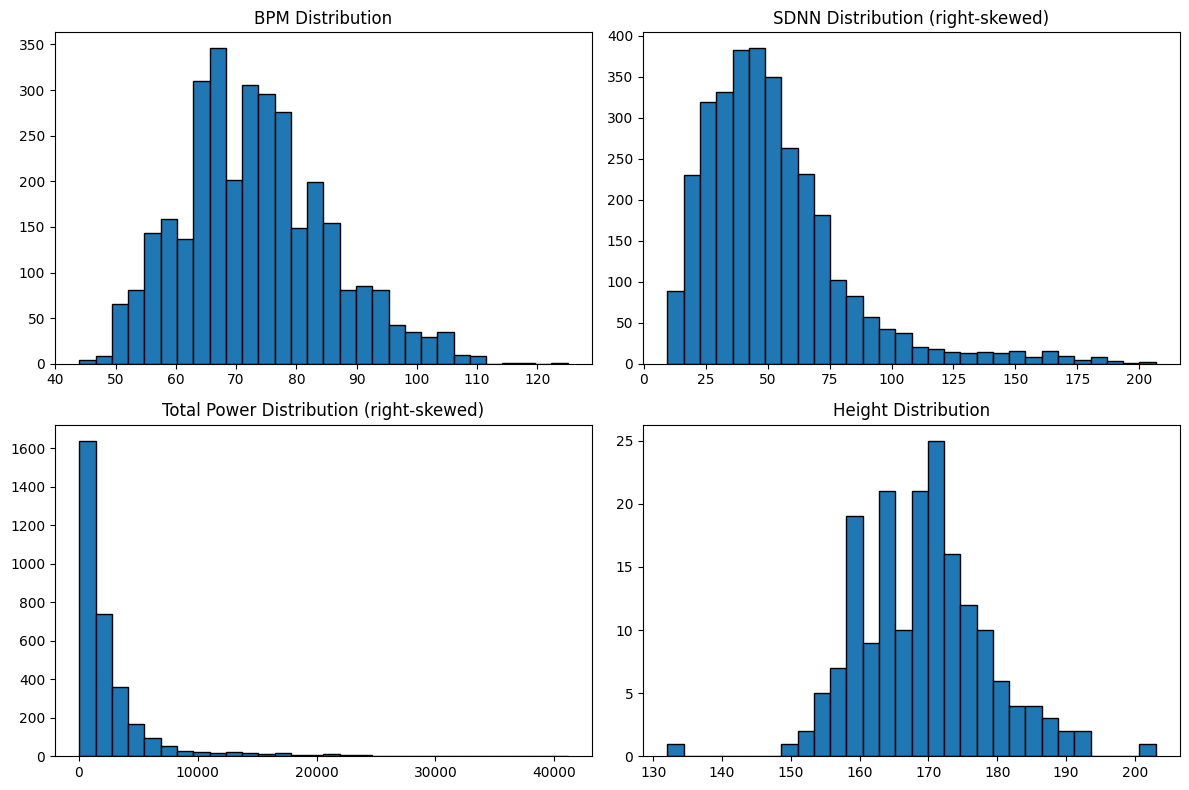

In [67]:
# Histograms

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0,0].hist(hrv['bpm'], bins=30, edgecolor='black')
axes[0,0].set_title('BPM Distribution')

axes[0,1].hist(hrv['sdnn'], bins=30, edgecolor='black')
axes[0,1].set_title('SDNN Distribution (right-skewed)')

axes[1,0].hist(hrv['total_power'], bins=30, edgecolor='black')
axes[1,0].set_title('Total Power Distribution (right-skewed)')

axes[1,1].hist(participants['height'].dropna(), bins=30, edgecolor='black')
axes[1,1].set_title('Height Distribution')

plt.tight_layout()
plt.show()

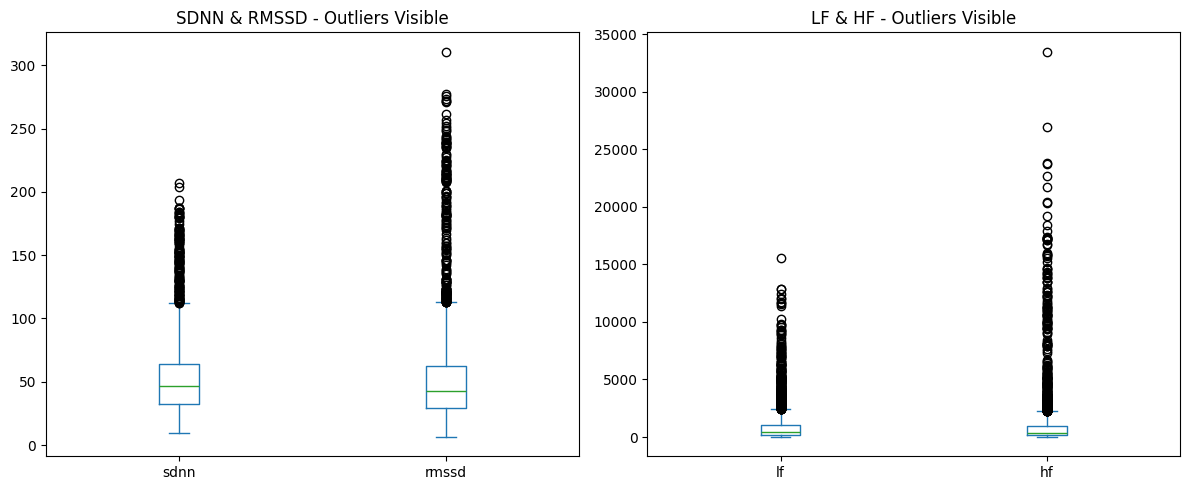

In [68]:
# Box plots 

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

hrv[['sdnn', 'rmssd']].plot(kind='box', ax=axes[0])
axes[0].set_title('SDNN & RMSSD - Outliers Visible')

hrv[['lf', 'hf']].plot(kind='box', ax=axes[1])
axes[1].set_title('LF & HF - Outliers Visible')

plt.tight_layout()
plt.show()

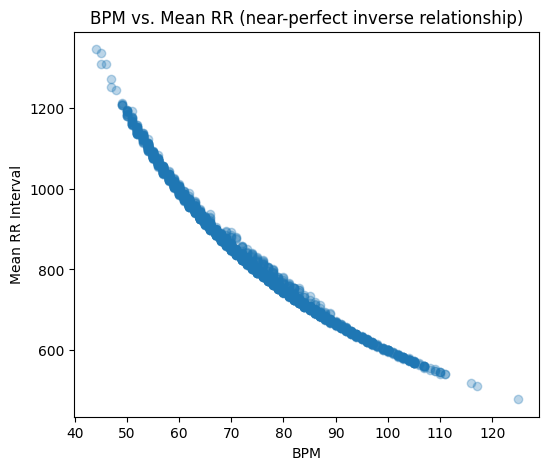

In [69]:
# Scatter plots

plt.figure(figsize=(6,5))
plt.scatter(merged['bpm'], merged['meanrr'], alpha=0.3)
plt.xlabel('BPM')
plt.ylabel('Mean RR Interval')
plt.title('BPM vs. Mean RR (near-perfect inverse relationship)')
plt.show()

## Interpretation

The histograms confirm the right-skew seen earlier in sdnn and total_power, while bpm and height look closer to normal. The box plots confirm the outliers that were found earlier (sdnn, rmssd, lf, and hf all have many points beyond the whiskers, with one extreme hf value near 33,000). Lastly, the scatter plot confirms the -0.98 correlation between bpm and meanrr, showing a smooth curve since meanrr is mathematically derived from bpm.

# Data Transformation and Feature Engineering

## Questions we are asking:
- How should the skewed HRV variables be transformed for analysis?
- What new feature can be engineered from this data, and why?

In [70]:
# Log transforming the skewed HRV columns
for col in ['sdnn', 'rmssd', 'lf', 'hf', 'vlf', 'total_power']:
    merged[f'{col}_log'] = np.log1p(merged[col])

print("Skewness before vs. after log transform:")
for col in ['sdnn', 'rmssd', 'lf', 'hf', 'vlf', 'total_power']:
    print(f"{col}: {merged[col].skew():.2f} -> {merged[f'{col}_log'].skew():.2f}")

# New feature: BMI, calculated from height and weight
merged['bmi'] = merged['weight'] / (merged['height'] / 100) ** 2
print(merged[['height', 'weight', 'bmi']].describe())

Skewness before vs. after log transform:
sdnn: 1.72 -> -0.03
rmssd: 2.66 -> 0.35
lf: 3.80 -> -0.24
hf: 5.34 -> 0.24
vlf: 6.05 -> -0.32
total_power: 3.79 -> -0.02
            height       weight          bmi
count  3235.000000  3245.000000  3235.000000
mean    169.540161    79.669604    27.765029
std       6.561023    19.999524     7.476938
min     132.080000    43.500000    16.288104
25%     166.000000    62.000000    22.303275
50%     168.000000    79.500000    26.808163
75%     175.000000    92.000000    31.249135
max     203.000000   154.221000    54.277185


## Interpretation

Log-transforming sdnn, rmssd, lf, hf, vlf, and total_power reduced their skewness, bringing all of them much closer to a normal distribution (example: hf skew dropped from 5.34 to 0.24). This makes these features more suitable for downstream statistical analysis or modeling that assumes roughly normal inputs. BMI was engineered from height and weight as a new feature. Body composition is a known physiological factor that can influence resting heart rate and HRV, so BMI may be a useful predictor in future modeling. The resulting BMI values, which range from 16.3 to 54.3 and have a median of 26.8 are reasonable within the real-world context, which gives some confidence that the underlying height/weight values (with the exception of the two heights that were removed) are reasonable.

### Handling Outliers

As identified in the Data Quality section, HRV metrics (sdnn, rmssd, lf, hf, vlf, total_power) have 1.6% to 3.2% of values flagged as being 3+ standard deviation outliers. Instead of removing or capping these values, they were kept in the dataset since extreme HRV readings can reflect real physiological states like illness or stress that may be relevant to this dataset's COVID-19 research context. Removing these could discard meaningful signal instead of "noise". The log transformation applied above reduces the influence of the extreme values on analysis without just throwing them out. The two implausible height values identified earlier were treated differently because tjey were determined to be data entry errors rather than legitimate extreme values and were already converted to missing (NaN). (I know this is a duplicate of what I said in my interpretation in the Data Quality section but am including it again here for the auto-grader)

# Interpretation for ML

After cleaning and transformation, with a few caveats, this dataset could reasonably support a model predicting HRV from demographic, environmental, and self-reported wellbeing factors. 

- Dimensions: The merged dataset has 3,245 rows and over 35 columns with weather data available for 78% of rows. A model using weather features would need to either drop the missing 22% or impute it.
- Data types: Most features are already numeric and ready to use. Categorical fields like gender, age_range, city, and country would need to be encoded first.
- Missing values: how_sleep and tags have 55% and 32% of values missing and thus are too incomplete to use reliably and were excluded here. symptoms_onset has 20% values missing and would need a similar decision if used later.
- Feature considerations: bpm and meanrr are redundant, which is reflected by their -0.98 correlation, so only one should be kept. sdnn, rmssd, lf, hf, vlf, and total_power are related but still 
each carry some unique information. Their log-transformed versions work better for models like linear regression, while tree-based models can handle the raw skewed values better.
- New feature: BMI adds physiological context that is not directly in the raw data and could help explain some of the variation in HRV.
- Sampling limitations: This is a sample of participants who opted in to the study rather than a representative one. This could introduce different sampling biases like volunteer bias, so any model built on it should be validated carefully before drawing broader conclusions.